# Phase 1 — Data understanding & preprocessing

**Dataset:** EmoPairCompete — `HR_data_2.csv` (pre-extracted biosignal features from the Empatica E4 wristband).

**Design recap (from the case description):** each of 26 participants completed 4 rounds, each round containing three 5-minute phases:

| label | meaning | expected arousal |
|-------|---------|------------------|
| `phase1` | Pre-puzzle rest (baseline) | low |
| `phase2` | Tangram puzzle competition (stress/frustration) | high |
| `phase3` | Post-puzzle recovery | intermediate |

So the 26 × 4 × 3 = 312 row count is exact and expected.

**Goal of this notebook:** go from the raw CSV to an analysis-ready feature matrix `X`, a phase-label vector `y`, and a `subject` ID vector, with every data-handling decision documented in one place.

In [119]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(context='notebook', style='whitegrid')
RNG = np.random.default_rng(0)

DATA_PATH = Path('data/HR_data_2.csv')
ART_DIR = Path('artifacts/case2_phase1')
ART_DIR.mkdir(parents=True, exist_ok=True)
print('artifacts dir ->', ART_DIR.resolve())

artifacts dir -> /Users/venello/Repositories/Python/PyCharm/PycharmProjects/computation_data_analysis/CDA_case_2/artifacts/case2_phase1


## 1. Load and inspect

The CSV ships with a leading unnamed index column; we treat it as such rather than a feature.

In [120]:
df = pd.read_csv(DATA_PATH, index_col=0)
print('shape:', df.shape)
df.head(3)

shape: (312, 70)


,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.73,0.9775,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.36,0.1900,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.63,0.3575,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0


In [121]:
df.dtypes.value_counts().rename('n_columns')

float64    62
str         5
int64       3
Name: n_columns, dtype: int64

### 1.1 Column semantics

We split the 70 columns into three groups so it is always clear what is an input, what is a label, and what is bookkeeping.

* **Biosignal features (51):** summary statistics of the HR, skin temperature (TEMP), phasic EDA (EDA_P) and tonic EDA (EDA_T) signals, plus three EDA peak-derived metrics (`Peaks`, `RT`, `ReT`).
* **Experimental metadata (8):** round, phase, subject identifiers, condition flag, path to raw signal.
* **Self-report labels (11):** I-PANAS-SF items + `Frustrated` VAS (recorded after each phase).

In [122]:
META_COLS = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID',
             'raw_data_path', 'Team_ID', 'Cohort']
PANAS_COLS = ['upset', 'hostile', 'alert', 'ashamed', 'inspired',
              'nervous', 'attentive', 'afraid', 'active', 'determined']
SELF_REPORT_COLS = ['Frustrated'] + PANAS_COLS
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + SELF_REPORT_COLS]

HR_COLS    = [c for c in FEATURE_COLS if c.startswith('HR_')]
TEMP_COLS  = [c for c in FEATURE_COLS if c.startswith('TEMP_')]
EDAP_COLS  = [c for c in FEATURE_COLS if c.startswith('EDA_TD_P_') and c not in ('EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT')]
EDAT_COLS  = [c for c in FEATURE_COLS if c.startswith('EDA_TD_T_')]
EDAPK_COLS = ['EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT']

print(f'metadata      : {len(META_COLS):3d} cols')
print(f'self-report   : {len(SELF_REPORT_COLS):3d} cols')
print(f'biosignal (X) : {len(FEATURE_COLS):3d} cols')
print(f'  HR          : {len(HR_COLS)}')
print(f'  TEMP        : {len(TEMP_COLS)}')
print(f'  EDA_P       : {len(EDAP_COLS)}')
print(f'  EDA_T       : {len(EDAT_COLS)}')
print(f'  EDA peaks   : {len(EDAPK_COLS)}')
assert len(META_COLS) + len(SELF_REPORT_COLS) + len(FEATURE_COLS) == df.shape[1]

metadata      :   8 cols
self-report   :  11 cols
biosignal (X) :  51 cols
  HR          : 12
  TEMP        : 12
  EDA_P       : 12
  EDA_T       : 12
  EDA peaks   : 3


### 1.2 Structural sanity checks

Is the 26 × 4 × 3 design actually balanced in the file?

In [123]:
print('n subjects (Individual):', df['Individual'].nunique())
print('n subjects (original_ID):', df['original_ID'].nunique(),
      '  <- non-unique after cohort renaming; use Individual as canonical ID')
print('observations per subject:', df.groupby('Individual').size().unique())
print('\nphase balance:')
print(df['Phase'].value_counts())
print('\nrounds per phase:')
print(pd.crosstab(df['Round'], df['Phase']))
print('\ncohort sizes (subjects per cohort):')
print(df.groupby('Cohort')['Individual'].nunique())
print('\nduplicate rows:', df.duplicated().sum())

n subjects (Individual): 26
n subjects (original_ID): 20   <- non-unique after cohort renaming; use Individual as canonical ID
observations per subject: [12]

phase balance:
Phase
phase3    104
phase2    104
phase1    104
Name: count, dtype: int64

rounds per phase:
Phase    phase1  phase2  phase3
Round                          
round_1      26      26      26
round_2      26      26      26
round_3      26      26      26
round_4      26      26      26

cohort sizes (subjects per cohort):
Cohort
D1_1    8
D1_2    6
D1_3    4
D1_4    4
D1_5    2
D1_6    2
Name: Individual, dtype: int64

duplicate rows: 0


Design is intact: each of the 26 subjects contributes exactly 12 rows (4 rounds × 3 phases), phases and rounds are perfectly balanced, no duplicates. The `original_ID` column collides across cohorts (20 uniques for 26 subjects), so we treat `Individual` as the canonical subject key from here on.

## 2. Missing-value audit

We count missingness separately for biosignal features and self-report labels, because they behave very differently.

In [124]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({'n_missing': miss, 'pct': miss_pct})

,n_missing,pct
inspired,2,0.64
determined,2,0.64
EDA_TD_P_RT,1,0.32
EDA_TD_P_ReT,1,0.32
attentive,1,0.32
afraid,1,0.32
active,1,0.32


In [125]:
bio_missing = df.loc[df[EDAPK_COLS].isna().any(axis=1),
                     ['Individual', 'Cohort', 'Round', 'Phase',
                      'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT']]
bio_missing

,Individual,Cohort,Round,Phase,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT
272,23,D1_3,round_4,phase1,1,NaN,NaN


**Interpretation.** Out of 312 × 51 = 15,912 biosignal cells, only **2 are missing** (the `RT` and `ReT` of subject 23, round 4, phase 1). That phase has `EDA_TD_P_Peaks = 1`, so rise-time / recovery-time are undefined when there is essentially no EDA event to measure — this is **MAR by sensor design**, not random drop-out. The remaining 7 missing cells are all in self-report columns (`inspired`, `attentive`, `afraid`, `active`, `determined`).

**Decision.** For the 2 biosignal cells we impute the column median (via `SimpleImputer` in the pipeline). We flag but do not impute the 7 PANAS cells — if a later analysis uses PANAS as a target, those rows can be dropped then.

In [126]:
per_subj_miss = df.groupby('Individual')[FEATURE_COLS].apply(lambda x: x.isna().sum().sum())
per_subj_miss[per_subj_miss > 0]

Individual
23    2
dtype: int64

## 3. Constant / near-constant features

In [127]:
def top_value_share(s):
    vc = s.value_counts(dropna=False, normalize=True)
    return vc.iloc[0] if len(vc) else np.nan

feat_stats = pd.DataFrame({
    'nunique': df[FEATURE_COLS].nunique(),
    'top_share': df[FEATURE_COLS].apply(top_value_share),
    'std': df[FEATURE_COLS].std(),
}).sort_values('top_share', ascending=False)
feat_stats.head(10)

,nunique,top_share,std
EDA_TD_P_Min,143,0.541667,0.130979
TEMP_TD_Slope_min,159,0.067308,0.000792
EDA_TD_P_Peaks,57,0.057692,12.378527
TEMP_TD_Slope_max,168,0.044872,0.000857
TEMP_TD_Slope,292,0.038462,0.000304
EDA_TD_P_ReT,254,0.025641,0.616643
TEMP_TD_Median,191,0.022436,1.645406
TEMP_TD_Max,190,0.022436,1.639815
EDA_TD_P_RT,257,0.019231,0.463986
TEMP_TD_Min,189,0.019231,1.652112


No biosignal feature has a single value covering >95 % of rows, and the smallest `nunique` is well above 1. **No feature is dropped for being constant.** (Two PANAS labels — `hostile`, `afraid` — are near-constant with >95 % of subjects giving the lowest rating; we note this for later label-based analyses but they are not model inputs.)

## 4. Summary statistics

In [128]:
HEADLINE = ['HR_TD_Mean', 'HR_TD_std',
            'TEMP_TD_Mean', 'TEMP_TD_Slope',
            'EDA_TD_P_Mean', 'EDA_TD_P_Peaks',
            'EDA_TD_T_Mean']

phase_summary = df.groupby('Phase')[HEADLINE].agg(['mean', 'std']).round(3)
phase_summary

HR_TD_Mean         HR_TD_std        TEMP_TD_Mean        TEMP_TD_Slope  \
             mean     std      mean    std         mean    std          mean   
Phase                                                                          
phase1     78.547  13.963     7.116  5.788       32.851  1.618           0.0   
phase2     79.821   8.643     6.588  4.201       32.953  1.650          -0.0   
phase3     77.282  10.876     5.932  4.858       32.912  1.674           0.0   

            EDA_TD_P_Mean        EDA_TD_P_Peaks         EDA_TD_T_Mean         
        std          mean    std           mean     std          mean    std  
Phase                                                                         
phase1  0.0         0.292  0.884         19.846  10.479         3.542  4.774  
phase2  0.0         0.597  1.280         32.385  12.717         3.390  4.738  
phase3  0.0         0.365  0.924         18.327   8.421         4.363  6.280

In [129]:
per_subject_mean = df.groupby('Individual')[HEADLINE].mean()
per_subject_mean.describe().round(3)

,HR_TD_Mean,HR_TD_std,TEMP_TD_Mean,TEMP_TD_Slope,EDA_TD_P_Mean,EDA_TD_P_Peaks,EDA_TD_T_Mean
count,26.000,26.000,26.000,26.0,26.000,26.000,26.000
mean,78.550,6.546,32.905,0.0,0.418,23.519,3.765
std,8.972,2.604,1.562,0.0,0.985,6.399,4.286
min,66.520,3.039,29.741,-0.0,0.003,13.750,0.187
25%,72.674,4.196,32.017,-0.0,0.036,19.688,0.952
50%,76.520,6.003,32.881,0.0,0.107,22.417,2.089
75%,82.965,8.267,34.407,0.0,0.359,28.000,5.317
max,100.914,11.337,35.332,0.0,4.984,43.333,17.676


Even after collapsing within-subject variability, **between-subject spread** on all headline features is large compared to the between-phase spread above — a first hint that subject-level baselines will dominate any model that does not account for them.

## 5. Visualisations

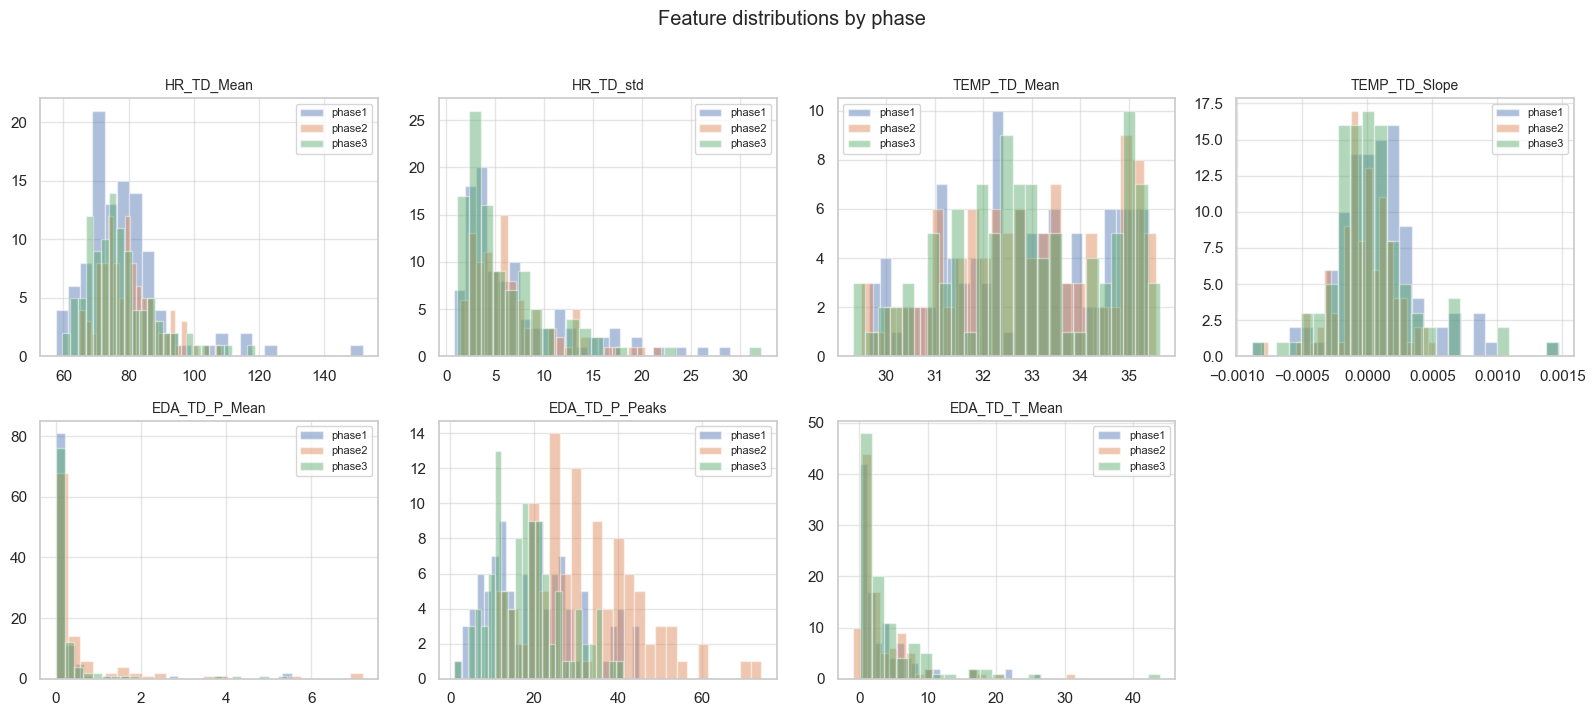

In [130]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), HEADLINE):
    for phase, g in df.groupby('Phase'):
        ax.hist(g[col].dropna(), bins=25, alpha=0.45, label=phase)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Feature distributions by phase', y=1.02)
plt.tight_layout()
plt.show()

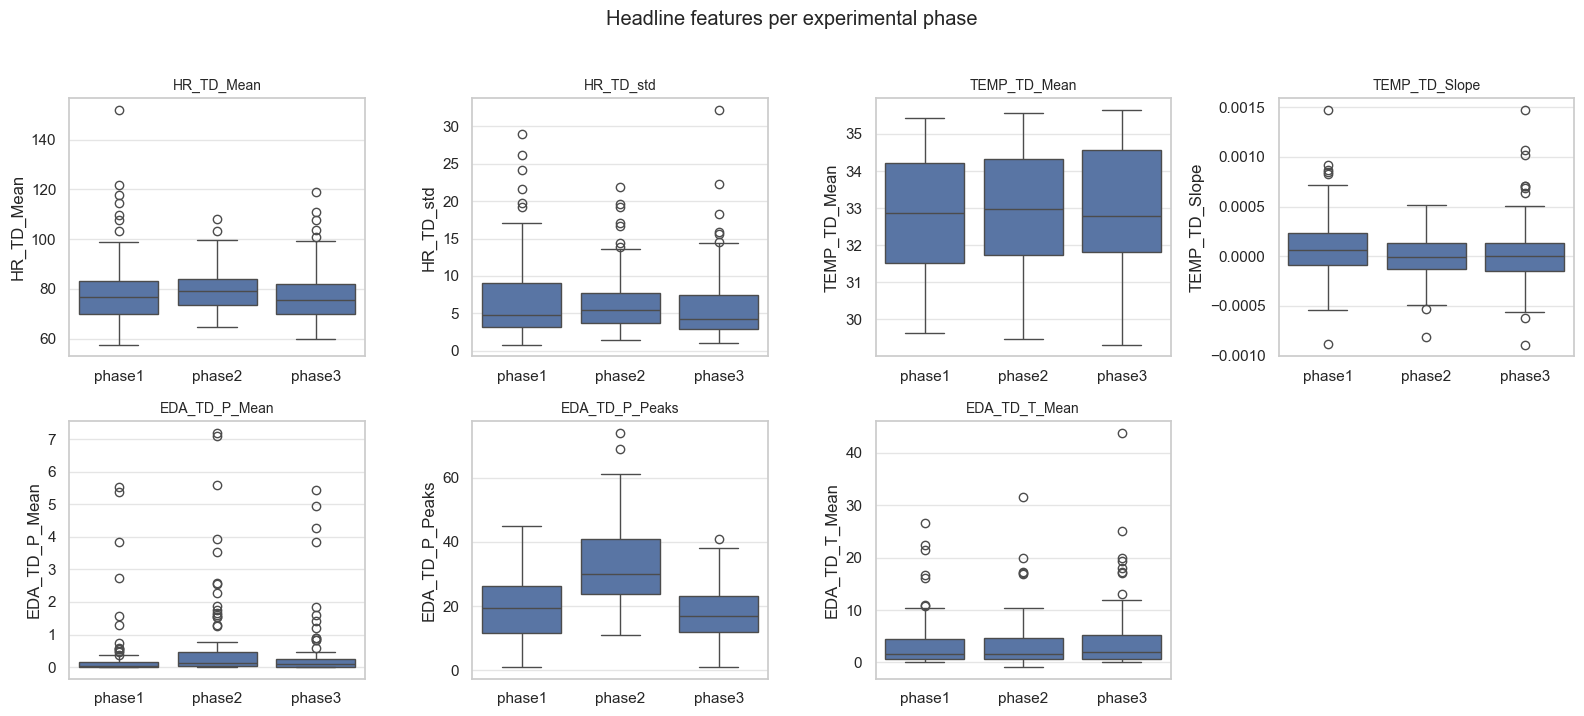

In [131]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), HEADLINE):
    sns.boxplot(data=df, x='Phase', y=col, order=['phase1','phase2','phase3'], ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
axes.ravel()[-1].axis('off')
plt.suptitle('Headline features per experimental phase', y=1.02)
plt.tight_layout()
plt.show()

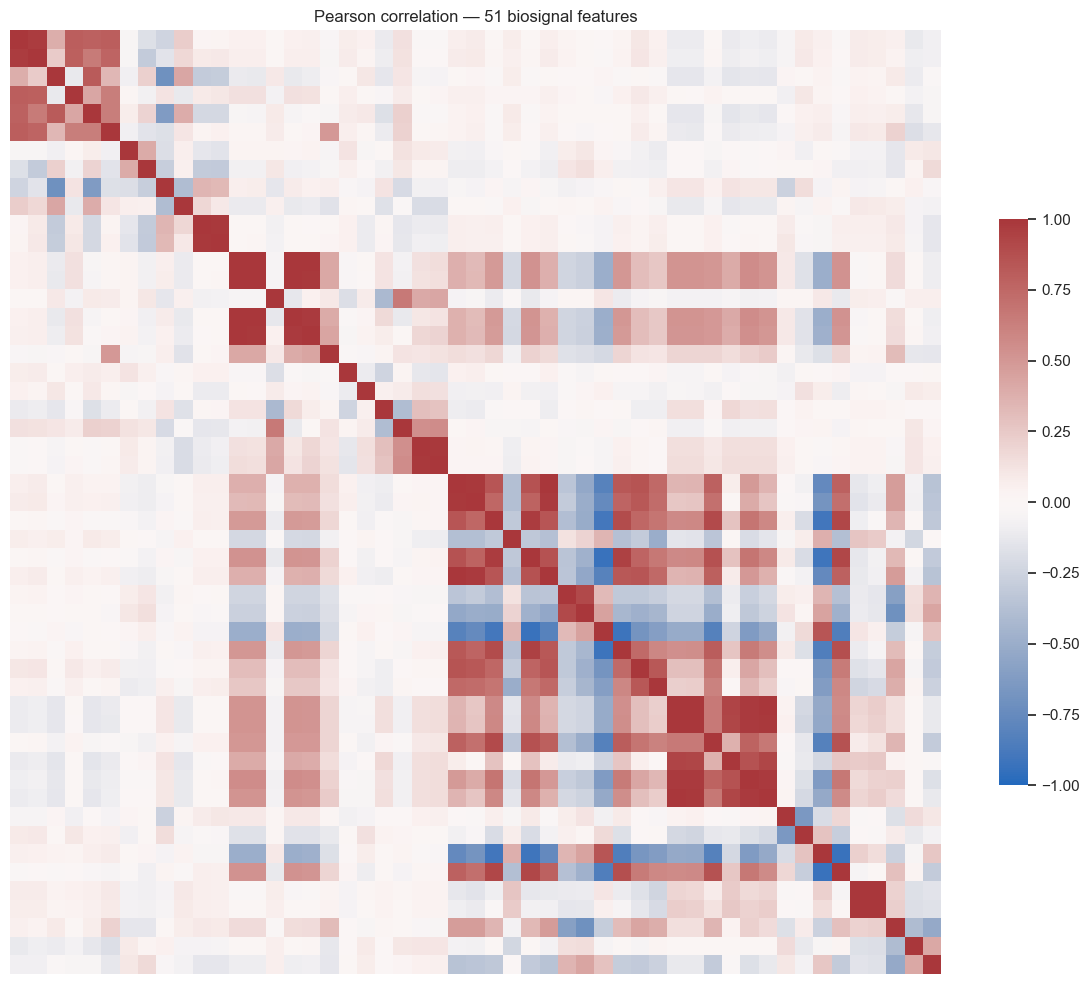

feature pairs with |r| > 0.95: 20


,f1,f2,r,abs_r
625,TEMP_TD_Mean,TEMP_TD_Median,0.999642,0.999642
1873,EDA_TD_T_Mean,EDA_TD_T_Median,0.998789,0.998789
1253,EDA_TD_P_Mean,EDA_TD_P_AUC,0.998695,0.998695
2393,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,0.995925,0.995925
627,TEMP_TD_Mean,TEMP_TD_Min,0.995718,0.995718
678,TEMP_TD_Median,TEMP_TD_Min,0.995023,0.995023
1877,EDA_TD_T_Mean,EDA_TD_T_AUC,0.993825,0.993825
628,TEMP_TD_Mean,TEMP_TD_Max,0.993797,0.993797
679,TEMP_TD_Median,TEMP_TD_Max,0.992119,0.992119
1928,EDA_TD_T_Median,EDA_TD_T_AUC,0.990674,0.990674


In [132]:
corr = df[FEATURE_COLS].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': .6})
plt.title(f'Pearson correlation — {len(FEATURE_COLS)} biosignal features')
plt.tight_layout()
plt.show()

triu = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
strong = (triu.stack()
            .rename('r')
            .reset_index()
            .rename(columns={'level_0': 'f1', 'level_1': 'f2'}))
strong['abs_r'] = strong['r'].abs()
strong = strong.sort_values('abs_r', ascending=False)
print(f"feature pairs with |r| > 0.95: {(strong['abs_r'] > 0.95).sum()}")
strong.head(10)

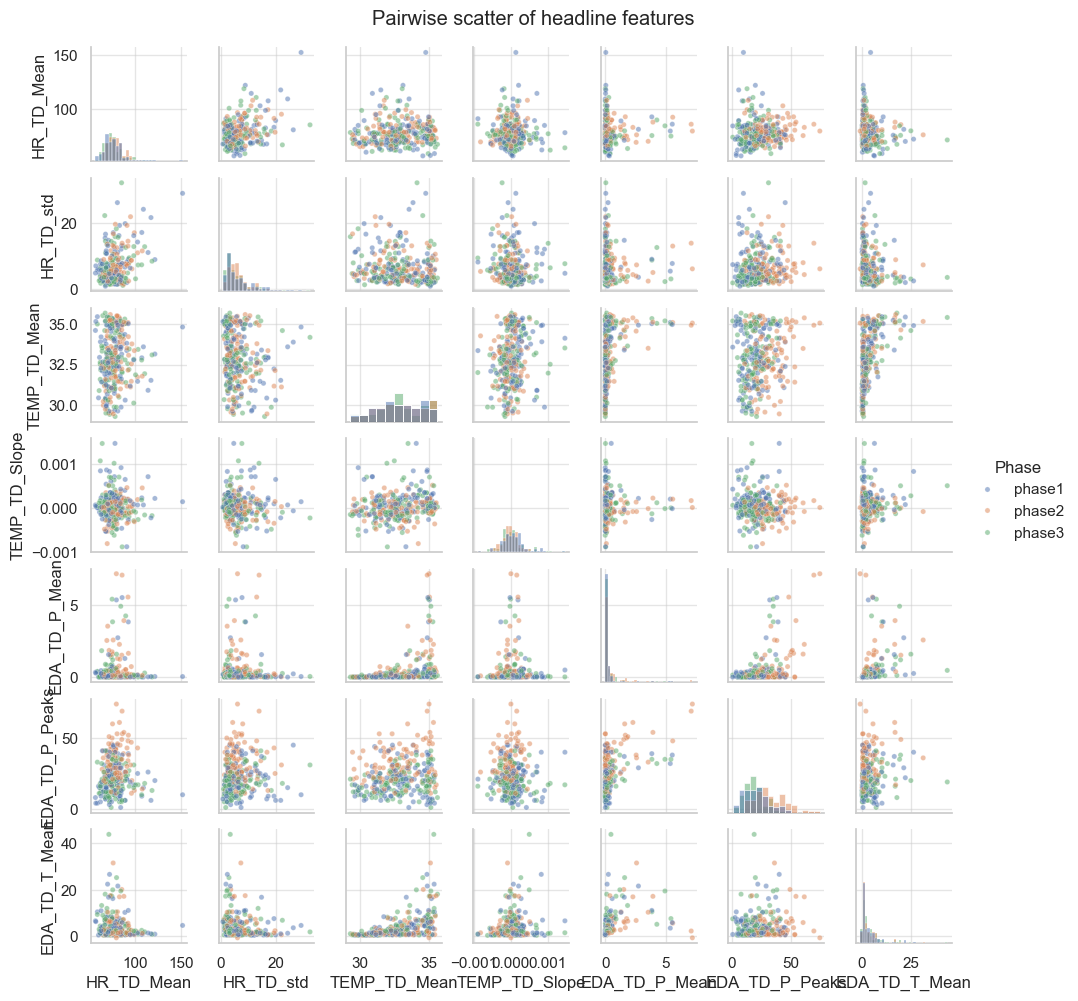

In [133]:
sns.pairplot(df[HEADLINE + ['Phase']], hue='Phase',
             hue_order=['phase1','phase2','phase3'],
             diag_kind='hist', plot_kws={'alpha':0.5, 's':14}, height=1.4)
plt.suptitle('Pairwise scatter of headline features', y=1.02)
plt.show()

**What the plots show.**
* The by-phase distributions and boxplots overlap heavily: the raw marginal separation between rest / puzzle / recovery is small relative to the overall spread — consistent with the case description's warning that the signal is weak.
* The correlation matrix has dense blocks inside each biosignal family (HR-mean / HR-median / HR-AUC; temperature statistics; tonic EDA statistics). There are several pairs with `|r| > 0.95`, which matters for CCA and linear models.
* The pairwise scatter shows clusters forming **by subject, not by phase** — visible as parallel subject-level streaks.

## 6. Data-quality & outlier audit

In [134]:
dup_feat_rows = df[FEATURE_COLS].duplicated().sum()
dup_full_rows = df.duplicated().sum()
print('duplicated feature rows:', dup_feat_rows)
print('duplicated full rows   :', dup_full_rows)

key_counts = df.groupby(['Individual','Round','Phase']).size()
print('(Individual, Round, Phase) uniqueness:', bool((key_counts == 1).all()),
      '— max count', int(key_counts.max()))

plausibility = {
    'HR_TD_Min < 30 bpm'  : int((df['HR_TD_Min']  < 30).sum()),
    'HR_TD_Max > 200 bpm' : int((df['HR_TD_Max']  > 200).sum()),
    'TEMP_TD_Min < 25 C'  : int((df['TEMP_TD_Min'] < 25).sum()),
    'TEMP_TD_Max > 40 C'  : int((df['TEMP_TD_Max'] > 40).sum()),
    'EDA_TD_P_Peaks == 0' : int((df['EDA_TD_P_Peaks'] == 0).sum()),
    'EDA_TD_T_Mean  < 0'  : int((df['EDA_TD_T_Mean']  < 0).sum()),
}
pd.Series(plausibility, name='n_rows')

duplicated feature rows: 3
duplicated full rows   : 0
(Individual, Round, Phase) uniqueness: True — max count 1


HR_TD_Min < 30 bpm     0
HR_TD_Max > 200 bpm    0
TEMP_TD_Min < 25 C     0
TEMP_TD_Max > 40 C     0
EDA_TD_P_Peaks == 0    0
EDA_TD_T_Mean  < 0     1
Name: n_rows, dtype: int64

In [135]:
z = (df[FEATURE_COLS] - df[FEATURE_COLS].mean()) / df[FEATURE_COLS].std()
outlier_counts = (z.abs() > 4).sum().sort_values(ascending=False)
print('features with >=1 |z|>4 row:', int((outlier_counts > 0).sum()), '/', len(FEATURE_COLS))
outlier_counts.head(10)

features with >=1 |z|>4 row: 44 / 51


EDA_TD_P_Slope         8
EDA_TD_P_Median        7
EDA_TD_P_AUC           7
EDA_TD_P_Mean          7
EDA_TD_P_Slope_mean    6
EDA_TD_T_Slope_min     5
EDA_TD_T_Median        4
EDA_TD_T_Mean          4
EDA_TD_P_Slope_max     4
EDA_TD_P_Slope_min     4
dtype: int64

**Data-quality findings.**

* No duplicate rows; the `(Individual, Round, Phase)` composite key is unique, so labels are internally consistent.
* No implausible HR, temperature or EDA values.
* Kurtosis / skew / slope-extremum features carry the usual heavy tails (expected for higher-order moments on short segments). We do **not** winsorize — downstream methods (PCA, CCA, one-class SVM) need the true variance structure, and `StandardScaler` with robust QC is sufficient.

## 7. Preprocessing decisions

| Step | Decision | Justification |
|------|----------|---------------|
| Metadata / label separation | drop 8 metadata + 11 self-report before fitting | keeps inputs cleanly physiological |
| Missing biosignal cells | median imputation via `SimpleImputer` | only 2/15,912 cells, MAR-by-design (no EDA peak → no RT/ReT) |
| Scaling | `StandardScaler` (z-score) | PCA/CCA are scale-sensitive; feature magnitudes span many orders |
| Correlated features | **flag, do not drop** | PCA/CCA handle redundancy natively; dropping risks losing within-family nuance |
| Subject-baseline centering | offered as an *optional* second matrix `X_subjz` | physiology has huge between-subject variance; not the default, to avoid silently changing the research question |

We wrap the first three steps in a single `sklearn.Pipeline` so every downstream notebook can start from a fitted, serialized pipeline and avoid re-deriving any of this.

In [136]:
X_raw    = df[FEATURE_COLS].copy()
y_phase  = df['Phase'].astype('category')
subject  = df['Individual'].to_numpy()
cohort   = df['Cohort'].to_numpy()
round_id = df['Round'].to_numpy()

preprocess = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

X = preprocess.fit_transform(X_raw)
X = pd.DataFrame(X, columns=FEATURE_COLS, index=df.index)
print('X shape:', X.shape,
      '  |mean|<1e-8?:', bool(float(np.abs(X.mean()).max()) < 1e-8),
      '  std~1?:', bool(np.allclose(X.std(ddof=0), 1.0, atol=1e-6)))
X.head(3)

X shape: (312, 51)   |mean|<1e-8?: True   std~1?: True


,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,EDA_TD_T_AUC,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT
0,0.010023,-0.062352,0.187214,-0.163880,0.001629,-0.312526,-0.621392,-0.007322,-0.414857,0.978121,...,-0.674626,0.276417,-1.310763,0.595726,-0.667286,0.135978,0.096659,-1.012991,1.134433,0.099784
1,-0.176801,-0.069806,-0.793634,0.111690,-0.570809,-0.086288,-0.114281,-0.045281,0.532375,-0.699948,...,-0.674647,0.136077,0.945391,0.595677,-0.666593,0.135187,0.095006,-0.689332,0.467560,0.290627
2,-0.033122,0.038688,-0.774299,0.369032,-0.544302,-0.988619,-0.336389,-0.740408,-0.158848,-0.343025,...,-0.680703,-0.072207,0.568117,0.596330,-0.667436,0.130645,0.091310,-1.093906,-0.055798,0.158532


In [137]:
X_subjz = X_raw.copy().astype(float)
for sid in np.unique(subject):
    idx = np.where(subject == sid)[0]
    block = X_raw.iloc[idx]
    sd = block.std(ddof=0).replace(0, 1)
    X_subjz.iloc[idx] = ((block - block.mean()) / sd).fillna(0).to_numpy()
print('X_subjz shape:', X_subjz.shape,
      '  per-subject mean ~ 0?:',
      bool(np.abs(X_subjz.groupby(subject).mean().to_numpy()).max() < 1e-8))


X_subjz shape: (312, 51)   per-subject mean ~ 0?: True


## 7.5 Categorical encoding

The 8 metadata columns were excluded from `X` above on purpose (labels, identifiers, or path strings). But three of them carry signal that can legitimately enter the feature matrix:

| column | encoding | rationale |
|--------|----------|-----------|
| `Puzzler` | binary 0/1 (already int) | who solved the tangram in this round can plausibly modulate physiology |
| `Round` | ordinal 1..4 | trial number captures fatigue / habituation |
| `Cohort` | one-hot (6 columns) | nuisance — different recording sessions; included so models can absorb session offsets |

We deliberately **do not** encode `Individual`, `Phase`, `original_ID`, `raw_data_path`, or `Team_ID`:
* `Individual` would let any model trivially memorise subject identity — that's what `X_subjz` is for.
* `Phase` is the target for phase-discrimination questions, so it cannot be a feature.
* The remaining three are bookkeeping with no predictive content.

In [138]:
puzzler_code = df['Puzzler'].astype(int).rename('puzzler')
round_code   = df['Round'].str.extract(r'round_(\d+)', expand=False).astype(int).rename('round_idx')
cohort_dum   = pd.get_dummies(df['Cohort'], prefix='cohort', dtype=float)

C = pd.concat([puzzler_code, round_code, cohort_dum], axis=1)
CAT_COLS = list(C.columns)

print('categorical block:', C.shape)
print('columns:', CAT_COLS)
C.head(3)

categorical block: (312, 8)
columns: ['puzzler', 'round_idx', 'cohort_D1_1', 'cohort_D1_2', 'cohort_D1_3', 'cohort_D1_4', 'cohort_D1_5', 'cohort_D1_6']


,puzzler,round_idx,cohort_D1_1,cohort_D1_2,cohort_D1_3,cohort_D1_4,cohort_D1_5,cohort_D1_6
0,1,3,0.0,0.0,0.0,1.0,0.0,0.0
1,1,3,0.0,0.0,0.0,1.0,0.0,0.0
2,1,3,0.0,0.0,0.0,1.0,0.0,0.0


## 7.6 Engineered features — within-round baseline deltas

The case design gives us a free baseline: in every round each subject does a `phase1` rest segment before the puzzle. Subtracting that round's rest values from the same subject's `phase2` and `phase3` rows gives a feature that **strips subject baseline AND round drift in one subtraction**, leaving only the within-round response to the manipulation.

For each row:

`delta_f = f − f_at_phase1_of_(same subject, same round)`

* `phase1` rows therefore have `delta = 0` by construction (they are their own baseline). Intentional: lets a model see rest segments as "no change from rest" instead of forcing us to drop them.
* This is *different* from `X_subjz` (per-subject z-score across all 12 rows of that subject), which mixes baselines from all 4 rounds and removes within-subject variance entirely. The delta features keep within-subject variance intact.
* We use the median-imputed biosignal values so the 2 missing cells in (subject 23, round 4, phase 1) don't propagate as NaN deltas.

In [139]:
imputed = pd.DataFrame(
    preprocess.named_steps['impute'].transform(X_raw),
    columns=FEATURE_COLS, index=df.index,
)

baseline_lookup = (imputed
                    .assign(_subject=df['Individual'].values,
                            _round=df['Round'].values,
                            _phase=df['Phase'].values)
                    .query('_phase == "phase1"')
                    .set_index(['_subject', '_round'])[FEATURE_COLS])

multi_idx = pd.MultiIndex.from_arrays(
    [df['Individual'].values, df['Round'].values],
    names=['_subject', '_round'],
)
baseline_aligned = baseline_lookup.reindex(multi_idx)
baseline_aligned.index = df.index

delta = imputed - baseline_aligned.to_numpy()
delta.columns = ['delta_' + c for c in FEATURE_COLS]
DELTA_COLS = list(delta.columns)

is_phase1 = (df['Phase'].to_numpy() == 'phase1')
assert np.allclose(delta.iloc[is_phase1].to_numpy(), 0.0), 'phase1 rows must have zero deltas'
print('delta block:', delta.shape, '— phase1 deltas exactly 0 ✓')
delta.head(3)

delta block: (312, 51) — phase1 deltas exactly 0 ✓


,delta_HR_TD_Mean,delta_HR_TD_Median,delta_HR_TD_std,delta_HR_TD_Min,delta_HR_TD_Max,delta_HR_TD_AUC,delta_HR_TD_Kurtosis,delta_HR_TD_Skew,delta_HR_TD_Slope_min,delta_HR_TD_Slope_max,...,delta_EDA_TD_T_AUC,delta_EDA_TD_T_Kurtosis,delta_EDA_TD_T_Skew,delta_EDA_TD_T_Slope_min,delta_EDA_TD_T_Slope_max,delta_EDA_TD_T_Slope_mean,delta_EDA_TD_T_Slope,delta_EDA_TD_P_Peaks,delta_EDA_TD_P_RT,delta_EDA_TD_P_ReT
0,0.490314,-1.22,4.798788,-4.97,9.68,2723.845,-0.475526,0.603002,-0.10,0.6200,...,39.908957,1.140180,-1.860015,-0.000032,0.000006,0.000009,0.000009,1.0,0.550505,-0.036111
1,-1.632831,-1.31,-0.096499,-2.40,-0.47,3635.315,0.370584,0.571779,0.27,-0.1675,...,39.770222,0.681194,0.373486,-0.000034,0.000033,0.000007,0.000006,5.0,0.242063,0.081197
2,0.000000,0.00,0.000000,0.00,0.00,0.000,0.000000,0.000000,0.00,0.0000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


## 7.7 Engineered feature matrix

We assemble three blocks side-by-side:

* **biosignal** (51) — `X` from §7, already z-scored.
* **delta** (51) — within-round deltas from §7.6, z-scored independently so they enter PCA/CCA on a comparable scale.
* **categorical** (8) — `puzzler`, `round_idx`, plus 6 cohort dummies; standardised so they aren't down-weighted just for being on a different scale.

This gives a **312 × 110 engineered feature matrix `X_eng`**. Downstream notebooks can either work with `X` (clean biosignal-only baseline) or `X_eng` (richer, with explicit experimental structure) — both are persisted in §8.

In [140]:
scaler_delta = StandardScaler().fit(delta)
delta_scaled = pd.DataFrame(scaler_delta.transform(delta),
                            columns=DELTA_COLS, index=df.index)

scaler_cat = StandardScaler().fit(C.astype(float))
C_scaled = pd.DataFrame(scaler_cat.transform(C.astype(float)),
                        columns=CAT_COLS, index=df.index)

X_eng = pd.concat([X, delta_scaled, C_scaled], axis=1)
ENG_COLS = list(X_eng.columns)

print('X_eng shape:', X_eng.shape,
      f'  ({len(FEATURE_COLS)} bio + {len(DELTA_COLS)} delta + {len(CAT_COLS)} cat)')
X_eng.head(3)

X_eng shape: (312, 110)   (51 bio + 51 delta + 8 cat)


,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,delta_EDA_TD_P_RT,delta_EDA_TD_P_ReT,puzzler,round_idx,cohort_D1_1,cohort_D1_2,cohort_D1_3,cohort_D1_4,cohort_D1_5,cohort_D1_6
0,0.010023,-0.062352,0.187214,-0.163880,0.001629,-0.312526,-0.621392,-0.007322,-0.414857,0.978121,...,1.126895,0.102248,1.0,0.447214,-0.666667,-0.547723,-0.426401,2.345208,-0.288675,-0.288675
1,-0.176801,-0.069806,-0.793634,0.111690,-0.570809,-0.086288,-0.114281,-0.045281,0.532375,-0.699948,...,0.596977,0.272822,1.0,0.447214,-0.666667,-0.547723,-0.426401,2.345208,-0.288675,-0.288675
2,-0.033122,0.038688,-0.774299,0.369032,-0.544302,-0.988619,-0.336389,-0.740408,-0.158848,-0.343025,...,0.181100,0.154756,1.0,0.447214,-0.666667,-0.547723,-0.426401,2.345208,-0.288675,-0.288675


## 8. Persist analysis-ready artefacts

Both a portable `.npz` (arrays only) and a richer `.pkl` (DataFrames + fitted pipeline) are saved, so downstream phases can choose.

In [141]:
npz_path = ART_DIR / 'case2_phase1_matrix.npz'
pkl_path = ART_DIR / 'case2_phase1_bundle.pkl'
pipe_path = ART_DIR / 'case2_phase1_preprocess_pipeline.pkl'

np.savez_compressed(
    npz_path,
    X=X.to_numpy(),
    X_subjz=X_subjz.to_numpy(),
    X_eng=X_eng.to_numpy(),
    delta=delta.to_numpy(),
    C=C.to_numpy(),
    y_phase=y_phase.cat.codes.to_numpy(),
    phase_labels=np.array(y_phase.cat.categories),
    subject=subject,
    cohort=cohort.astype(str),
    round_id=round_id.astype(str),
    feature_names=np.array(FEATURE_COLS),
    delta_names=np.array(DELTA_COLS),
    cat_names=np.array(CAT_COLS),
    eng_names=np.array(ENG_COLS),
)

bundle = {
    'X': X,
    'X_subjz': X_subjz,
    'X_eng': X_eng,
    'delta': delta,
    'C': C,
    'y_phase': y_phase,
    'subject': subject,
    'cohort': cohort,
    'round_id': round_id,
    'feature_cols': FEATURE_COLS,
    'delta_cols': DELTA_COLS,
    'cat_cols': CAT_COLS,
    'eng_cols': ENG_COLS,
    'panas': df[PANAS_COLS],
    'frustrated': df['Frustrated'],
    'puzzler': df['Puzzler'],
}
joblib.dump(bundle, pkl_path)
joblib.dump(preprocess, pipe_path)

for p in (npz_path, pkl_path, pipe_path):
    print(f'{p}  ({p.stat().st_size/1024:.1f} KB)')

artifacts/case2_phase1/case2_phase1_matrix.npz  (498.2 KB)
artifacts/case2_phase1/case2_phase1_bundle.pkl  (712.5 KB)
artifacts/case2_phase1/case2_phase1_preprocess_pipeline.pkl  (3.6 KB)


## 9. Summary, findings, and proposed research questions

### Key findings from EDA
1. **Dataset is complete and balanced.** 312 rows = 26 subjects × 4 rounds × 3 phases, with no duplicates and consistent composite keys.
2. **Missingness is negligible and structural.** 2 biosignal cells (EDA rise-/recovery-time on a segment with a single EDA peak) and 7 self-report cells. Median imputation handles the former; the latter are left for target-specific handling.
3. **No constant or implausible features.** All 51 biosignal features pass sensor-range plausibility checks.
4. **Between-phase separation is weak; between-subject spread is large.** Boxplots of headline HR / TEMP / EDA features overlap across phases, while subject-mean features vary substantially. Any unsupervised model is at real risk of recovering *subject identity* rather than *phase*.
5. **Features are internally redundant.** Multiple pairs have `|r| > 0.95` inside each biosignal family. PCA / CCA are natural tools; dropping features is unnecessary.

### Preprocessing & feature engineering (final pipeline)
* **Base biosignal matrix `X` (312 × 51):** `SimpleImputer(median) → StandardScaler` on the 51 biosignal columns.
* **Optional `X_subjz` (312 × 51):** per-subject z-score for analyses that want to factor out subject baselines entirely.
* **Categorical block `C` (312 × 8):** `puzzler` (binary), `round_idx` (ordinal 1..4), 6 one-hot cohort dummies. `Individual`, `Phase`, `original_ID`, `raw_data_path`, `Team_ID` deliberately excluded — see §7.5.
* **Within-round delta block `delta` (312 × 51):** `f − f_phase1_of_same_(subject, round)`. Strips subject baseline and round drift in one subtraction; phase1 rows are 0 by construction.
* **Engineered feature matrix `X_eng` (312 × 110):** `[X | delta_scaled | C_scaled]`. Downstream notebooks can pick `X` for a clean biosignal-only view or `X_eng` for the richer one with explicit experimental structure.

### Proposed research questions (for group confirmation)
1. **Representation.** Does PCA / CCA on the 51 biosignal features reveal a low-dimensional subspace whose axes have a physiological interpretation (arousal, thermoregulation, tonic EDA drift)? Compare what changes when fitting on `X` vs `X_eng`.
2. **Phase vs. subject.** Do unsupervised clusters (K-means / GMM) align with experimental phase, or do they recover subject identity? Quantify with ARI against both `Phase` and `Individual`. Expect the delta block to sharpen the phase signal.
3. **Zero-shot stress detection.** Can a One-Class SVM trained on phase 1 (rest) flag phase 2 (puzzle) as anomalous above chance, and how much survives a Leave-One-Subject-Out evaluation?
4. **Physiology ↔ self-report.** Using CCA between biosignal features (and/or the delta block) and PANAS ratings, is there a stable physiology–affect axis, or is the coupling dominated by a few subjects?

### Handoff
* `phase1_data.ipynb` — this notebook.
* `artifacts/case2_phase1/case2_phase1_matrix.npz` — `X`, `X_subjz`, `X_eng`, `delta`, `C`, `y_phase`, `subject`, `cohort`, `round_id`, plus all column-name arrays.
* `artifacts/case2_phase1/case2_phase1_bundle.pkl` — same as the `.npz` plus PANAS / `Frustrated` / `Puzzler` as DataFrames.
* `artifacts/case2_phase1/case2_phase1_preprocess_pipeline.pkl` — fitted `SimpleImputer → StandardScaler` for reproducible reuse.